In [ ]:
!pip install mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 391.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 23.7 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.4
    Uninstalling protobuf-5.29.4:
      Successfully uninstalled protobuf-5.29.4
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.7 which is incompatible.
grpcio

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1

In [ ]:
# %% [markdown]
# ### Import Libraries
# %%
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import keras
import tensorflow as tf # Import tensorflow for Swish activation

# %% [markdown]
# ### Define Custom Layer
#
# Define the custom SiluLayer class to handle the 'Silu' activation during model loading.
# %%
class SiluLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Use the Swish activation from Keras/TensorFlow
        return keras.activations.swish(inputs)

    def get_config(self):
        config = super().get_config()
        return config

# %% [markdown]
# ### Load the Trained Model
#
# Load the model, specifying the custom object 'Silu' to be mapped to our SiluLayer.
# %%
# Load model dengan custom objects, termasuk custom layer Silu
# Pastikan path model sesuai dengan lokasi model Anda di Google Drive
model_path = '/content/drive/MyDrive/PDM/model_ujicoba.keras' # Gunakan ekstensi .keras jika Anda menyimpannya dalam format native Keras

try:
    model = load_model(model_path, custom_objects={'Silu': SiluLayer})
    print("Model berhasil dimuat.")
except Exception as e:
    print(f"Error saat memuat model: {e}")

# %% [markdown]
# ### Preprocessing Function
#
# Function to load and preprocess the input image.
# %%
def preprocess_landmark_image(img_path, img_size=256):
    # Baca gambar dalam format warna (3 channels)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")

    # Resize gambar
    img_resized = cv2.resize(img, (img_size, img_size))

    # Normalisasi nilai piksel ke rentang [0, 1]
    img_norm = img_resized / 255.0

    # Tambahkan dimensi batch
    input_tensor = np.expand_dims(img_norm, axis=0).astype(np.float32)

    return input_tensor, img_resized

# %% [markdown]
# ### Upload and Predict
#
# Upload an image, preprocess it, make a prediction, and display the result.
# %%
if model is not None:
    # Upload gambar landmark dari komputer lokal
    print("Silakan unggah file gambar untuk prediksi:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"Memproses file: {filename}")

        try:
            # Preprocessing gambar
            input_tensor, img_display = preprocess_landmark_image(filename, img_size=img_size)

            # Prediksi
            preds = model.predict(input_tensor)
            predicted_class_index = np.argmax(preds, axis=1)[0]
            confidence = preds[0][predicted_class_index]

            # Label (sesuaikan dengan label kelas Anda)
            # Jika kelas Anda adalah huruf A-Z, ini sudah benar
            labels = [chr(i) for i in range(ord('a'), ord('z')+1)]
            if 0 <= predicted_class_index < len(labels):
                 predicted_label = labels[predicted_class_index]
            else:
                 predicted_label = "Tidak Diketahui"


            print(f"Prediksi kelas: {predicted_label} dengan confidence: {confidence:.4f}")

            # Tampilkan gambar
            plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)) # Tampilkan dalam warna
            plt.title(f"Prediksi: {predicted_label} ({confidence:.2%})")
            plt.axis('off')
            plt.show()

        except FileNotFoundError as e:
            print(e)
        except Exception as e:
            print(f"Terjadi error saat memproses file {filename}: {e}")
else:
    print("Model tidak dapat dimuat, prediksi tidak dapat dilakukan.")

# %%

In [ ]:
# %% [markdown]
# ### Import Libraries
# %%
from google.colab import files
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import keras
import tensorflow as tf # Import tensorflow for Swish activation

# %% [markdown]
# ### Define Custom Layer
#
# Define the custom SiluLayer class to handle the 'Silu' activation during model loading.
# %%
class SiluLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Use the Swish activation from Keras/TensorFlow
        return keras.activations.swish(inputs)

    def get_config(self):
        config = super().get_config()
        return config

# %% [markdown]
# ### Load the Trained Model
#
# Load the model, specifying the custom object 'Silu' to be mapped to our SiluLayer.
# %%
# Load model dengan custom objects, termasuk custom layer Silu
# Pastikan path model sesuai dengan lokasi model Anda di Google Drive
model_path = '/content/drive/MyDrive/PDM/model_ujicoba.keras' # Gunakan ekstensi .keras jika Anda menyimpannya dalam format native Keras

try:
    model = load_model(model_path, custom_objects={'Silu': SiluLayer})
    print("Model berhasil dimuat.")
except Exception as e:
    print(f"Error saat memuat model: {e}")

# %% [markdown]
# ### Preprocessing Function
#
# Function to load and preprocess the input image.
# %%
def preprocess_landmark_image(img_path, img_size=256):
    # Baca gambar dalam format warna (3 channels)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {img_path}")

    # Resize gambar
    img_resized = cv2.resize(img, (img_size, img_size))

    # Normalisasi nilai piksel ke rentang [0, 1]
    img_norm = img_resized / 255.0

    # Tambahkan dimensi batch
    input_tensor = np.expand_dims(img_norm, axis=0).astype(np.float32)

    return input_tensor, img_resized

# %% [markdown]
# ### Upload and Predict
#
# Upload an image, preprocess it, make a prediction, and display the result.
# %%
if model is not None:
    # Upload gambar landmark dari komputer lokal
    print("Silakan unggah file gambar untuk prediksi:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"Memproses file: {filename}")

        try:
            # Preprocessing gambar
            input_tensor, img_display = preprocess_landmark_image(filename, img_size=img_size)

            # Prediksi
            preds = model.predict(input_tensor)
            predicted_class_index = np.argmax(preds, axis=1)[0]
            confidence = preds[0][predicted_class_index]

            # Label (sesuaikan dengan label kelas Anda)
            # Jika kelas Anda adalah huruf A-Z, ini sudah benar
            labels = [chr(i) for i in range(ord('a'), ord('z')+1)]
            if 0 <= predicted_class_index < len(labels):
                 predicted_label = labels[predicted_class_index]
            else:
                 predicted_label = "Tidak Diketahui"


            print(f"Prediksi kelas: {predicted_label} dengan confidence: {confidence:.4f}")

            # Tampilkan gambar
            plt.imshow(cv2.cvtColor(img_display, cv2.COLOR_BGR2RGB)) # Tampilkan dalam warna
            plt.title(f"Prediksi: {predicted_label} ({confidence:.2%})")
            plt.axis('off')
            plt.show()

        except FileNotFoundError as e:
            print(e)
        except Exception as e:
            print(f"Terjadi error saat memproses file {filename}: {e}")
else:
    print("Model tidak dapat dimuat, prediksi tidak dapat dilakukan.")

# %%

# 2

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from tensorflow.keras.models import load_model
import keras
from tensorflow.keras import layers
from google.colab import files
import matplotlib.pyplot as plt
import os

# --- Custom Layer sesuai model ---
class SiluLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def call(self, inputs):
        return keras.activations.swish(inputs)
    def get_config(self):
        return super().get_config()

# --- Load model ---
model_path = '/content/drive/MyDrive/PDM/model_ujicoba.keras'  # Sesuaikan path model
model = load_model(model_path, custom_objects={'Silu': SiluLayer})
print("Model berhasil dimuat.")

# --- Inisialisasi MediaPipe Hands ---
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.7)

# --- Fungsi untuk konversi landmark 2 tangan ke citra grayscale 256x256 ---
def landmarks_to_grayscale_image(landmarks_list, img_size=256, point_radius=5):
    zero_hand = np.zeros(42, dtype=np.float32)
    if len(landmarks_list) == 0:
        hand1 = zero_hand
        hand2 = zero_hand
    elif len(landmarks_list) == 1:
        hand1 = landmarks_list[0]
        hand2 = zero_hand
    else:
        avg_x_0 = np.mean(landmarks_list[0][0::2])
        avg_x_1 = np.mean(landmarks_list[1][0::2])
        if avg_x_0 < avg_x_1:
            hand_left = landmarks_list[0]
            hand_right = landmarks_list[1]
        else:
            hand_left = landmarks_list[1]
            hand_right = landmarks_list[0]

        hand1 = hand_right
        hand2 = hand_left

    # Gabungkan x,y dari kedua tangan
    x_coords = []
    y_coords = []
    for hand in [hand1, hand2]:
        x_coords.extend(hand[0::2])
        y_coords.extend(hand[1::2])
    x_coords = np.array(x_coords)
    y_coords = np.array(y_coords)

    # Tangani NaN (kalau ada)
    x_coords = np.nan_to_num(x_coords, 0)
    y_coords = np.nan_to_num(y_coords, 0)

    # Normalisasi agar semua titik berada di kanvas 256x256 dan di tengah
    min_x, max_x = np.min(x_coords), np.max(x_coords)
    min_y, max_y = np.min(y_coords), np.max(y_coords)

    x_range = max_x - min_x if max_x - min_x > 0 else 1
    y_range = max_y - min_y if max_y - min_y > 0 else 1

    scale_x = (img_size - 1) / x_range
    scale_y = (img_size - 1) / y_range

    # Offset agar titik berada di tengah
    offset_x = (img_size - (max_x - min_x) * scale_x) / 2
    offset_y = (img_size - (max_y - min_y) * scale_y) / 2

    # Buat canvas hitam
    canvas = np.zeros((img_size, img_size), dtype=np.uint8)

    # Gambar titik landmark sebagai lingkaran putih
    for x, y in zip(x_coords, y_coords):
        x_c = int((x - min_x) * scale_x + offset_x)
        y_c = int((y - min_y) * scale_y + offset_y)
        if 0 <= x_c < img_size and 0 <= y_c < img_size:
            cv2.circle(canvas, (x_c, y_c), point_radius, (255,), thickness=-1)

    return canvas

# --- Fungsi prediksi dari gambar upload ---
def predict_from_rgb_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = hands.process(img_rgb)

    landmarks_list = []
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            landmarks_2d = []
            for lm in hand_landmarks.landmark:
                landmarks_2d.append(lm.x)
                landmarks_2d.append(lm.y)
            landmarks_list.append(np.array(landmarks_2d, dtype=np.float32))

        # Konversi landmark ke citra grayscale 256x256
        landmark_img = landmarks_to_grayscale_image(landmarks_list)

        # Normalisasi pixel ke [0,1] dan ubah shape jadi (1,256,256,1)
        input_tensor = landmark_img.astype(np.float32) / 255.0
        input_tensor = np.stack([input_tensor]*3, axis=-1)  # Ubah 1 channel jadi 3 channel
        input_tensor = np.expand_dims(input_tensor, axis=0)  # Bentuk batch size 1

        # Prediksi dengan model
        preds = model.predict(input_tensor)
        predicted_class_index = np.argmax(preds, axis=1)[0]
        confidence = preds[0][predicted_class_index]

        labels = [chr(i) for i in range(ord('a'), ord('z')+1)]
        predicted_label = labels[predicted_class_index] if 0 <= predicted_class_index < len(labels) else "Tidak Diketahui"

        return img_rgb, landmark_img, predicted_label, confidence
    else:
        return img_rgb, None, None, None

# --- Upload dan prediksi ---
print("Silakan upload gambar tangan:")
uploaded = files.upload()

for filename in uploaded.keys():
    try:
        img_rgb, landmark_img, label, conf = predict_from_rgb_image(filename)
        if label is None:
            print(f"Tangan tidak terdeteksi pada gambar {filename}.")
            plt.imshow(img_rgb)
            plt.title("Tangan tidak terdeteksi")
            plt.axis('off')
            plt.show()
        else:
            print(f"Prediksi untuk {filename}: {label} dengan confidence {conf:.4f}")
            # Tampilkan gambar asli dan citra landmark
            plt.figure(figsize=(10,5))
            plt.subplot(1,2,1)
            plt.imshow(img_rgb)
            plt.title("Gambar Asli")
            plt.axis('off')

            plt.subplot(1,2,2)
            plt.imshow(landmark_img, cmap='gray')
            plt.title("Landmark 2D Grayscale")
            plt.axis('off')

            plt.show()
    except Exception as e:
        print(f"Error saat memproses {filename}: {e}")


In [ ]:
import cv2
import numpy as np
import mediapipe as mp
from tensorflow.keras.models import load_model
import keras
from tensorflow.keras import layers
from google.colab import files
import matplotlib.pyplot as plt
import os

# --- Custom Layer sesuai model ---
class SiluLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    def call(self, inputs):
        return keras.activations.swish(inputs)
    def get_config(self):
        return super().get_config()

# --- Load model ---
model_path = '/content/drive/MyDrive/PDM/model_ujicoba.keras'  # Sesuaikan path model
model = load_model(model_path, custom_objects={'Silu': SiluLayer})
print("Model berhasil dimuat.")

# --- Inisialisasi MediaPipe Hands ---
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5)

# --- Fungsi untuk konversi landmark 2 tangan ke citra grayscale 256x256 ---
def landmarks_to_grayscale_image(landmarks_list, img_size=256, point_radius=5):
    zero_hand = np.zeros(42, dtype=np.float32)
    if len(landmarks_list) == 0:
        hand1 = zero_hand
        hand2 = zero_hand
    elif len(landmarks_list) == 1:
        hand1 = landmarks_list[0]
        hand2 = zero_hand
    else:
        avg_x_0 = np.mean(landmarks_list[0][0::2])
        avg_x_1 = np.mean(landmarks_list[1][0::2])
        if avg_x_0 < avg_x_1:
            hand_left = landmarks_list[0]
            hand_right = landmarks_list[1]
        else:
            hand_left = landmarks_list[1]
            hand_right = landmarks_list[0]

        hand1 = hand_right
        hand2 = hand_left

    # Gabungkan x,y dari kedua tangan
    x_coords = []
    y_coords = []
    for hand in [hand1, hand2]:
        x_coords.extend(hand[0::2])
        y_coords.extend(hand[1::2])
    x_coords = np.array(x_coords)
    y_coords = np.array(y_coords)

    # Tangani NaN (kalau ada)
    x_coords = np.nan_to_num(x_coords, 0)
    y_coords = np.nan_to_num(y_coords, 0)

    # Normalisasi agar semua titik berada di kanvas 256x256 dan di tengah
    min_x, max_x = np.min(x_coords), np.max(x_coords)
    min_y, max_y = np.min(y_coords), np.max(y_coords)

    x_range = max_x - min_x if max_x - min_x > 0 else 1
    y_range = max_y - min_y if max_y - min_y > 0 else 1

    scale_x = (img_size - 1) / x_range
    scale_y = (img_size - 1) / y_range

    # Offset agar titik berada di tengah
    offset_x = (img_size - (max_x - min_x) * scale_x) / 2
    offset_y = (img_size - (max_y - min_y) * scale_y) / 2

    # Buat canvas hitam
    canvas = np.zeros((img_size, img_size), dtype=np.uint8)

    # Gambar titik landmark sebagai lingkaran putih
    for x, y in zip(x_coords, y_coords):
        x_c = int((x - min_x) * scale_x + offset_x)
        y_c = int((y - min_y) * scale_y + offset_y)
        if 0 <= x_c < img_size and 0 <= y_c < img_size:
            cv2.circle(canvas, (x_c, y_c), point_radius, (255,), thickness=-1)

    return canvas

# --- Fungsi prediksi dari gambar upload ---
def predict_from_rgb_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Gambar tidak ditemukan: {image_path}")
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = hands.process(img_rgb)

    landmarks_list = []
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            landmarks_2d = []
            for lm in hand_landmarks.landmark:
                landmarks_2d.append(lm.x)
                landmarks_2d.append(lm.y)
            landmarks_list.append(np.array(landmarks_2d, dtype=np.float32))

        # Konversi landmark ke citra grayscale 256x256
        landmark_img = landmarks_to_grayscale_image(landmarks_list)

        # Normalisasi pixel ke [0,1] dan ubah shape jadi (1,256,256,1)
        input_tensor = landmark_img.astype(np.float32) / 255.0
        input_tensor = np.stack([input_tensor]*3, axis=-1)  # Ubah 1 channel jadi 3 channel
        input_tensor = np.expand_dims(input_tensor, axis=0)  # Bentuk batch size 1

        # Prediksi dengan model
        preds = model.predict(input_tensor)
        predicted_class_index = np.argmax(preds, axis=1)[0]
        confidence = preds[0][predicted_class_index]

        labels = [chr(i) for i in range(ord('a'), ord('z')+1)]
        predicted_label = labels[predicted_class_index] if 0 <= predicted_class_index < len(labels) else "Tidak Diketahui"

        return img_rgb, landmark_img, predicted_label, confidence
    else:
        return img_rgb, None, None, None

# --- Upload dan prediksi ---
print("Silakan upload gambar tangan:")
uploaded = files.upload()

for filename in uploaded.keys():
    try:
        img_rgb, landmark_img, label, conf = predict_from_rgb_image(filename)
        if label is None:
            print(f"Tangan tidak terdeteksi pada gambar {filename}.")
            plt.imshow(img_rgb)
            plt.title("Tangan tidak terdeteksi")
            plt.axis('off')
            plt.show()
        else:
            print(f"Prediksi untuk {filename}: {label} dengan confidence {conf:.4f}")
            # Tampilkan gambar asli dan citra landmark
            plt.figure(figsize=(10,5))
            plt.subplot(1,2,1)
            plt.imshow(img_rgb)
            plt.title("Gambar Asli")
            plt.axis('off')

            plt.subplot(1,2,2)
            plt.imshow(landmark_img, cmap='gray')
            plt.title("Landmark 2D Grayscale")
            plt.axis('off')

            plt.show()
    except Exception as e:
        print(f"Error saat memproses {filename}: {e}")


# 3

Model berhasil dimuat.
MediaPipe Hands diinisialisasi.
Silakan unggah file gambar untuk prediksi:


Saving Screenshot 2025-05-16 212219.png to Screenshot 2025-05-16 212219.png
Memproses file: Screenshot 2025-05-16 212219.png
Memproses deteksi tangan dengan MediaPipe...
Hasil deteksi tangan MediaPipe: 2 tangan terdeteksi.


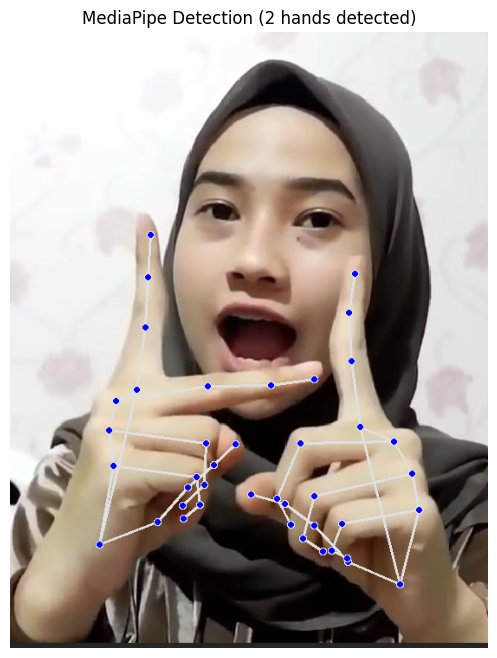


--- Debugging Input Tensor to Model ---
Shape of input_tensor: (1, 256, 256, 3)
Data type of input_tensor: float32
Min/Max value of input_tensor: 0.0 1.0
---------------------------------------

Melakukan prediksi dengan model...
1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step

--- Debugging Raw Predictions ---
Raw predictions: [[0.00637599 0.00890627 0.01103609 0.03646572 0.00959039 0.0032833
  0.00553961 0.48688224 0.00964785 0.00504498 0.05161622 0.01046162
  0.00821533 0.00975101 0.01906143 0.01477046 0.00459959 0.00956866
  0.01111155 0.16756509 0.01380592 0.0205246  0.02817326 0.02601974
  0.01563765 0.00634548]]
Sum of raw predictions: 1.0000001
Predicted class index: 7
Confidence: 0.48688224
------------------------------


--- HASIL PREDIKSI AKHIR ---
Prediksi kelas: h dengan confidence: 0.4869
-----------------------------



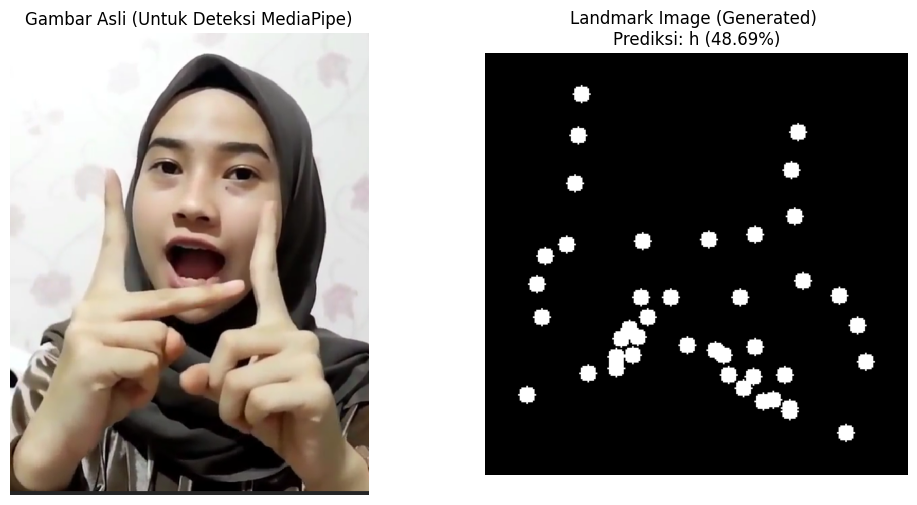

In [ ]:
# %% [markdown]
# ### Import Libraries
# %%
import cv2
import numpy as np
import mediapipe as mp
from tensorflow.keras.models import load_model
import keras # Masih dibutuhkan untuk custom layer dan activations
from tensorflow.keras import layers # Masih dibutuhkan untuk custom layer
from google.colab import files
import matplotlib.pyplot as plt
import os
import tensorflow as tf # Masih dibutuhkan jika custom layer atau bagian lain menggunakannya

# %% [markdown]
# ### Define Custom Layer
#
# Define the custom SiluLayer class to handle the 'Silu' activation during model loading.
# This is necessary so `load_model` knows how to handle the custom layer.
# %%
class SiluLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # Use the Swish activation from Keras/TensorFlow
        return keras.activations.swish(inputs)

    def get_config(self):
        # Pastikan get_config() mengembalikan konfigurasi
        config = super().get_config()
        return config

# %% [markdown]
# ### Load the Trained Model
#
# Load the model, specifying the custom object 'Silu' to be mapped to our SiluLayer.
# %%
# Pastikan variabel seperti num_classes dan img_size juga didefinisikan,
# karena mungkin dibutuhkan oleh fungsi preprocessing atau pelabelan.
# Sesuaikan ini agar sesuai dengan model training Anda
num_classes = 26 # Sesuaikan
img_size = 256   # Sesuaikan

model_path = '/content/drive/MyDrive/PDM/model_ujicoba.keras' # Gunakan ekstensi .keras

model = None # Inisialisasi model ke None
try:
    # Coba muat model utuh termasuk arsitektur dan bobot
    model = load_model(model_path, custom_objects={'Silu': SiluLayer})
    print("Model berhasil dimuat.")
except Exception as e:
    print(f"Error saat memuat model: {e}")
    model = None
    print("Tidak dapat memuat model.")
    print("Pastikan path model sudah benar dan custom object 'SiluLayer' terdefinisi.")


# %% [markdown]
# ### Initialize MediaPipe Hands
# %%
if model is not None: # Hanya inisialisasi MediaPipe jika model berhasil dimuat
    mp_hands = mp.solutions.hands
    # Sesuaikan min_detection_confidence jika perlu untuk debugging deteksi
    hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.5) # Contoh menurunkan confidence
    mp_drawing = mp.solutions.drawing_utils # Untuk visualisasi deteksi MediaPipe
    print("MediaPipe Hands diinisialisasi.")
else:
     print("Model gagal dimuat, MediaPipe Hands tidak diinisialisasi.")


# %% [markdown]
# ### Function to Convert Landmarks to Grayscale Image
# %%
# --- Fungsi untuk konversi landmark 2 tangan ke citra grayscale 256x256 ---
# Fungsi ini tetap dibutuhkan untuk mengubah output MediaPipe menjadi format input model
def landmarks_to_grayscale_image(landmarks_list, img_size=256, point_radius=5):
    # Membuat array kosong untuk 42 landmark (21 * 2) dengan nilai 0.0
    zero_hand = np.zeros(42, dtype=np.float32)

    hand1 = zero_hand
    hand2 = zero_hand

    if len(landmarks_list) == 1:
        hand1 = landmarks_list[0]
    elif len(landmarks_list) >= 2:
        # Tentukan tangan kiri dan kanan berdasarkan posisi X rata-rata
        avg_x_0 = np.mean(landmarks_list[0][0::2])
        avg_x_1 = np.mean(landmarks_list[1][0::2])

        if avg_x_0 < avg_x_1:
            hand_left = landmarks_list[0]
            hand_right = landmarks_list[1]
        else:
            hand_left = landmarks_list[1]
            hand_right = landmarks_list[0]

        hand1 = hand_right  # Tangan pertama adalah tangan kanan (misalnya)
        hand2 = hand_left   # Tangan kedua adalah tangan kiri (misalnya)
        # Sesuaikan urutan ini jika model Anda dilatih dengan urutan berbeda!
        # Penting: Urutan landmark di dalam hand1 dan hand2 juga harus konsisten (21 landmark * x,y)

    # Gabungkan x,y dari kedua tangan (42 landmark x 2 koordinat = 84 nilai)
    x_coords = []
    y_coords = []
    for hand in [hand1, hand2]:
        x_coords.extend(hand[0::2]) # Ambil semua koordinat x (indeks genap)
        y_coords.extend(hand[1::2]) # Ambil semua koordinat y (indeks ganjil)
    x_coords = np.array(x_coords)
    y_coords = np.array(y_coords)

    # Tangani NaN (kalau ada), ganti dengan 0. Ini penting agar min/max tidak error
    x_coords = np.nan_to_num(x_coords, 0)
    y_coords = np.nan_to_num(y_coords, 0)

    # Normalisasi agar semua titik berada di kanvas 256x256 dan di tengah
    # Hanya hitung min/max dari koordinat yang tidak nol (jika ada tangan yang nol_hand)
    valid_x = x_coords[(x_coords != 0) | (y_coords != 0)] # Ambil koordinat x yang bukan (0,0)
    valid_y = y_coords[(x_coords != 0) | (y_coords != 0)] # Ambil koordinat y yang bukan (0,0)

    if len(valid_x) > 0 and len(valid_y) > 0:
        min_x, max_x = np.min(valid_x), np.max(valid_x)
        min_y, max_y = np.min(valid_y), np.max(valid_y)
    else:
        # Jika tidak ada tangan terdeteksi (valid_x/y kosong), gunakan rentang default 0-1
        # Ini akan menghasilkan citra hitam
        min_x, max_x = 0, 1
        min_y, max_y = 0, 1


    x_range = max_x - min_x if max_x - min_x > 0 else 1e-6 # Hindari pembagian nol
    y_range = max_y - min_y if max_y - min_y > 0 else 1e-6 # Hindari pembagian nol

    # Tambahkan sedikit padding agar landmark tidak menempel di tepi
    padding = 0.1 # 10% padding dari ukuran gambar
    effective_img_size = img_size * (1 - 2 * padding)

    # Hitung skala berdasarkan rentang landmark dan ukuran efektif canvas
    scale_x = effective_img_size / x_range
    scale_y = effective_img_size / y_range

    # Hitung offset untuk centering termasuk padding
    # (ukuran canvas - ukuran landmark setelah diskalakan) / 2
    offset_x = (img_size - (max_x - min_x) * scale_x) / 2
    offset_y = (img_size - (max_y - min_y) * scale_y) / 2


    # Buat canvas hitam (grayscale) dengan tipe data uint8
    canvas = np.zeros((img_size, img_size), dtype=np.uint8)

    # Gambar titik landmark sebagai lingkaran putih
    # Iterasi melalui semua 84 titik (42 dari hand1, 42 dari hand2)
    for i in range(len(x_coords)):
        x, y = x_coords[i], y_coords[i]
        # Hanya gambar jika titik tersebut bukan dari 'zero_hand' placeholder
        # Yaitu, jika x atau y tidak nol
        if x != 0 or y != 0:
             # Terapkan normalisasi dan offset
             x_c = int((x - min_x) * scale_x + offset_x)
             y_c = int((y - min_y) * scale_y + offset_y)

             # Pastikan koordinat ada di dalam batas canvas sebelum menggambar
             if 0 <= x_c < img_size and 0 <= y_c < img_size:
                 cv2.circle(canvas, (x_c, y_c), point_radius, (255,), thickness=-1) # (255,) untuk grayscale putih


    # Ubah dari grayscale (H, W) menjadi BGR (H, W, 3)
    canvas_bgr = cv2.cvtColor(canvas, cv2.COLOR_GRAY2BGR)

    # Normalisasi nilai piksel ke rentang [0, 1] (untuk input model)
    canvas_norm = canvas_bgr.astype(np.float32) / 255.0


    return canvas_norm


# %% [markdown]
# ### Prediction Function
# %%
def predict_from_rgb_image(image_path):
    if model is None:
        print("Model belum berhasil dimuat. Tidak bisa melakukan prediksi.")
        return None, None, None, None, None

    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Gambar tidak ditemukan di {image_path}")
        return None, None, None, None, None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Gunakan RGB untuk MediaPipe

    print("Memproses deteksi tangan dengan MediaPipe...")
    results = hands.process(img_rgb)
    num_detected_hands = len(results.multi_hand_landmarks) if results.multi_hand_landmarks else 0
    print(f"Hasil deteksi tangan MediaPipe: {num_detected_hands} tangan terdeteksi.")

    # --- Visualisasikan Deteksi MediaPipe (untuk debugging) ---
    annotated_image = img_rgb.copy()
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            mp_drawing.draw_landmarks(
                annotated_image,
                hand_landmarks,
                mp_hands.HAND_CONNECTIONS)

    plt.figure(figsize=(8, 8))
    plt.imshow(annotated_image)
    plt.title(f"MediaPipe Detection ({num_detected_hands} hands detected)")
    plt.axis('off')
    plt.show()
    # --- Akhir Visualisasi ---


    landmarks_list = []
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            landmarks_2d = []
            for lm in hand_landmarks.landmark:
                # Ambil koordinat x dan y (sudah dinormalisasi oleh MediaPipe)
                landmarks_2d.append(lm.x) # x: [0, 1] relative to image width
                landmarks_2d.append(lm.y) # y: [0, 1] relative to image height
            landmarks_list.append(np.array(landmarks_2d, dtype=np.float32))

    # Konversi landmark menjadi citra 256x256, BGR, dan normalisasi [0,1]
    landmark_img_norm = landmarks_to_grayscale_image(landmarks_list, img_size=img_size)

    # Tambahkan dimensi batch untuk input model (model expects (batch_size, H, W, C))
    input_tensor = np.expand_dims(landmark_img_norm, axis=0) # landmark_img_norm is already float32

    # --- DEBUGGING: Periksa input tensor ---
    print("\n--- Debugging Input Tensor to Model ---")
    print("Shape of input_tensor:", input_tensor.shape)
    print("Data type of input_tensor:", input_tensor.dtype)
    print("Min/Max value of input_tensor:", np.min(input_tensor), np.max(input_tensor))
    print("---------------------------------------\n")


    # Prediksi
    print("Melakukan prediksi dengan model...")
    preds = model.predict(input_tensor)
    predicted_class_index = np.argmax(preds, axis=1)[0]
    confidence = preds[0][predicted_class_index]

    # --- DEBUGGING: Periksa output prediksi mentah ---
    print("\n--- Debugging Raw Predictions ---")
    print("Raw predictions:", preds)
    print("Sum of raw predictions:", np.sum(preds)) # Harusnya mendekati 1 jika softmax
    print("Predicted class index:", predicted_class_index)
    print("Confidence:", confidence)
    print("------------------------------\n")


    # Label (sesuaikan dengan label kelas Anda saat training)
    # Jika Anda menggunakan 'a'...'z' saat training di ImageDataGenerator
    # ImageDataGenerator akan menetapkan kelas 0 ke folder 'a', 1 ke 'b', dst.
    labels = [chr(i) for i in range(ord('a'), ord('z')+1)]
    # Jika Anda menggunakan 'A'...'Z' saat training
    # labels = [chr(i) for i in range(ord('A'), ord('Z')+1)]
    # Jika urutan kelas Anda berbeda, Anda perlu menyesuaikan daftar 'labels' ini
    # Berdasarkan output train_gen.class_indices saat training!


    predicted_label = "Tidak Diketahui"
    if 0 <= predicted_class_index < len(labels):
         predicted_label = labels[predicted_class_index]
    else:
         print(f"Warning: Predicted index {predicted_class_index} out of bounds for labels list ({len(labels)} classes).")


    return predicted_label, confidence, landmark_img_norm, img_rgb, landmarks_list


# %% [markdown]
# ### Upload and Predict
#
# Upload an image, preprocess it, make a prediction, and display the result.
# %%
# Hanya jalankan bagian prediksi jika model berhasil dimuat
if model is not None:
    print("Silakan unggah file gambar untuk prediksi:")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"Memproses file: {filename}")

        try:
            # Panggil fungsi prediksi
            predicted_label, confidence, landmark_img_norm, original_img_rgb, detected_landmarks_list = predict_from_rgb_image(filename)

            if predicted_label is not None: # Cek apakah prediksi berhasil
                print(f"\n--- HASIL PREDIKSI AKHIR ---")
                print(f"Prediksi kelas: {predicted_label} dengan confidence: {confidence:.4f}")
                print(f"-----------------------------\n")

                # Tampilkan citra asli dan citra landmark yang dihasilkan
                plt.figure(figsize=(12, 6)) # Ukuran figure yang lebih lebar
                plt.subplot(1, 2, 1)
                plt.imshow(original_img_rgb)
                plt.title("Gambar Asli (Untuk Deteksi MediaPipe)")
                plt.axis('off')

                plt.subplot(1, 2, 2)
                # landmark_img_norm adalah float32 [0,1] BGR. Konversi ke uint8 [0,255] RGB untuk display
                plt.imshow(cv2.cvtColor((landmark_img_norm*255).astype(np.uint8), cv2.COLOR_BGR2RGB))
                plt.title(f"Landmark Image (Generated) \nPrediksi: {predicted_label} ({confidence:.2%})")
                plt.axis('off')
                plt.show()

                if not detected_landmarks_list:
                    print("Catatan: Tidak ada landmark tangan yang terdeteksi oleh MediaPipe di gambar ini.")

            else:
                print("Prediksi gagal untuk file ini.")


        except FileNotFoundError as e:
            print(e)
        except Exception as e:
            print(f"Terjadi error saat memproses file {filename}: {e}")
else:
    print("Tidak dapat menjalankan prediksi karena model tidak berhasil dimuat.")